In [498]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from mpl_toolkits import mplot3d
from sklearn.model_selection import ParameterGrid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE


import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [499]:
df=pd.read_csv('nbarookiesdataset.csv')

In [500]:
df.describe()


,Id,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,6856.971000,62.777875,18.576662,7.267088,2.807037,6.231212,44.608900,0.264525,0.816562,19.583700,...,1.947788,71.365825,1.077838,2.168500,3.245300,1.624513,0.648687,0.245212,1.257763,0.833625
std,3977.447579,17.118774,8.935263,4.318732,1.693373,3.584559,6.155453,0.384093,1.060964,16.003155,...,1.252352,10.430447,0.785670,1.392224,2.085154,1.355986,0.407626,0.821037,0.723270,0.372440
min,4.000000,-8.000000,2.900000,0.800000,0.300000,0.800000,21.300000,-1.100000,-3.100000,-38.500000,...,0.000000,-13.300000,0.000000,0.200000,0.300000,0.000000,0.000000,-17.900000,0.100000,0.000000
25%,3413.750000,51.000000,12.000000,4.100000,1.600000,3.600000,40.400000,0.000000,0.100000,8.400000,...,1.000000,65.000000,0.500000,1.100000,1.700000,0.700000,0.300000,0.100000,0.700000,1.000000
50%,6787.500000,63.000000,16.800000,6.300000,2.400000,5.400000,44.400000,0.300000,0.800000,19.500000,...,1.700000,71.400000,0.900000,1.900000,2.800000,1.300000,0.600000,0.200000,1.100000,1.000000
75%,10299.250000,74.000000,23.500000,9.500000,3.700000,8.100000,48.700000,0.500000,1.500000,30.600000,...,2.600000,77.500000,1.500000,2.900000,4.300000,2.200000,0.900000,0.400000,1.600000,1.000000
max,13798.000000,123.000000,73.800000,34.200000,13.100000,28.900000,67.200000,1.700000,4.700000,82.100000,...,11.100000,168.900000,5.500000,11.000000,15.900000,12.800000,3.600000,18.900000,5.300000,1.000000


In [501]:
print ("We have",df.shape[0],"rows and",df.shape[1],"atributes")

We have 8000 rows and 21 atributes


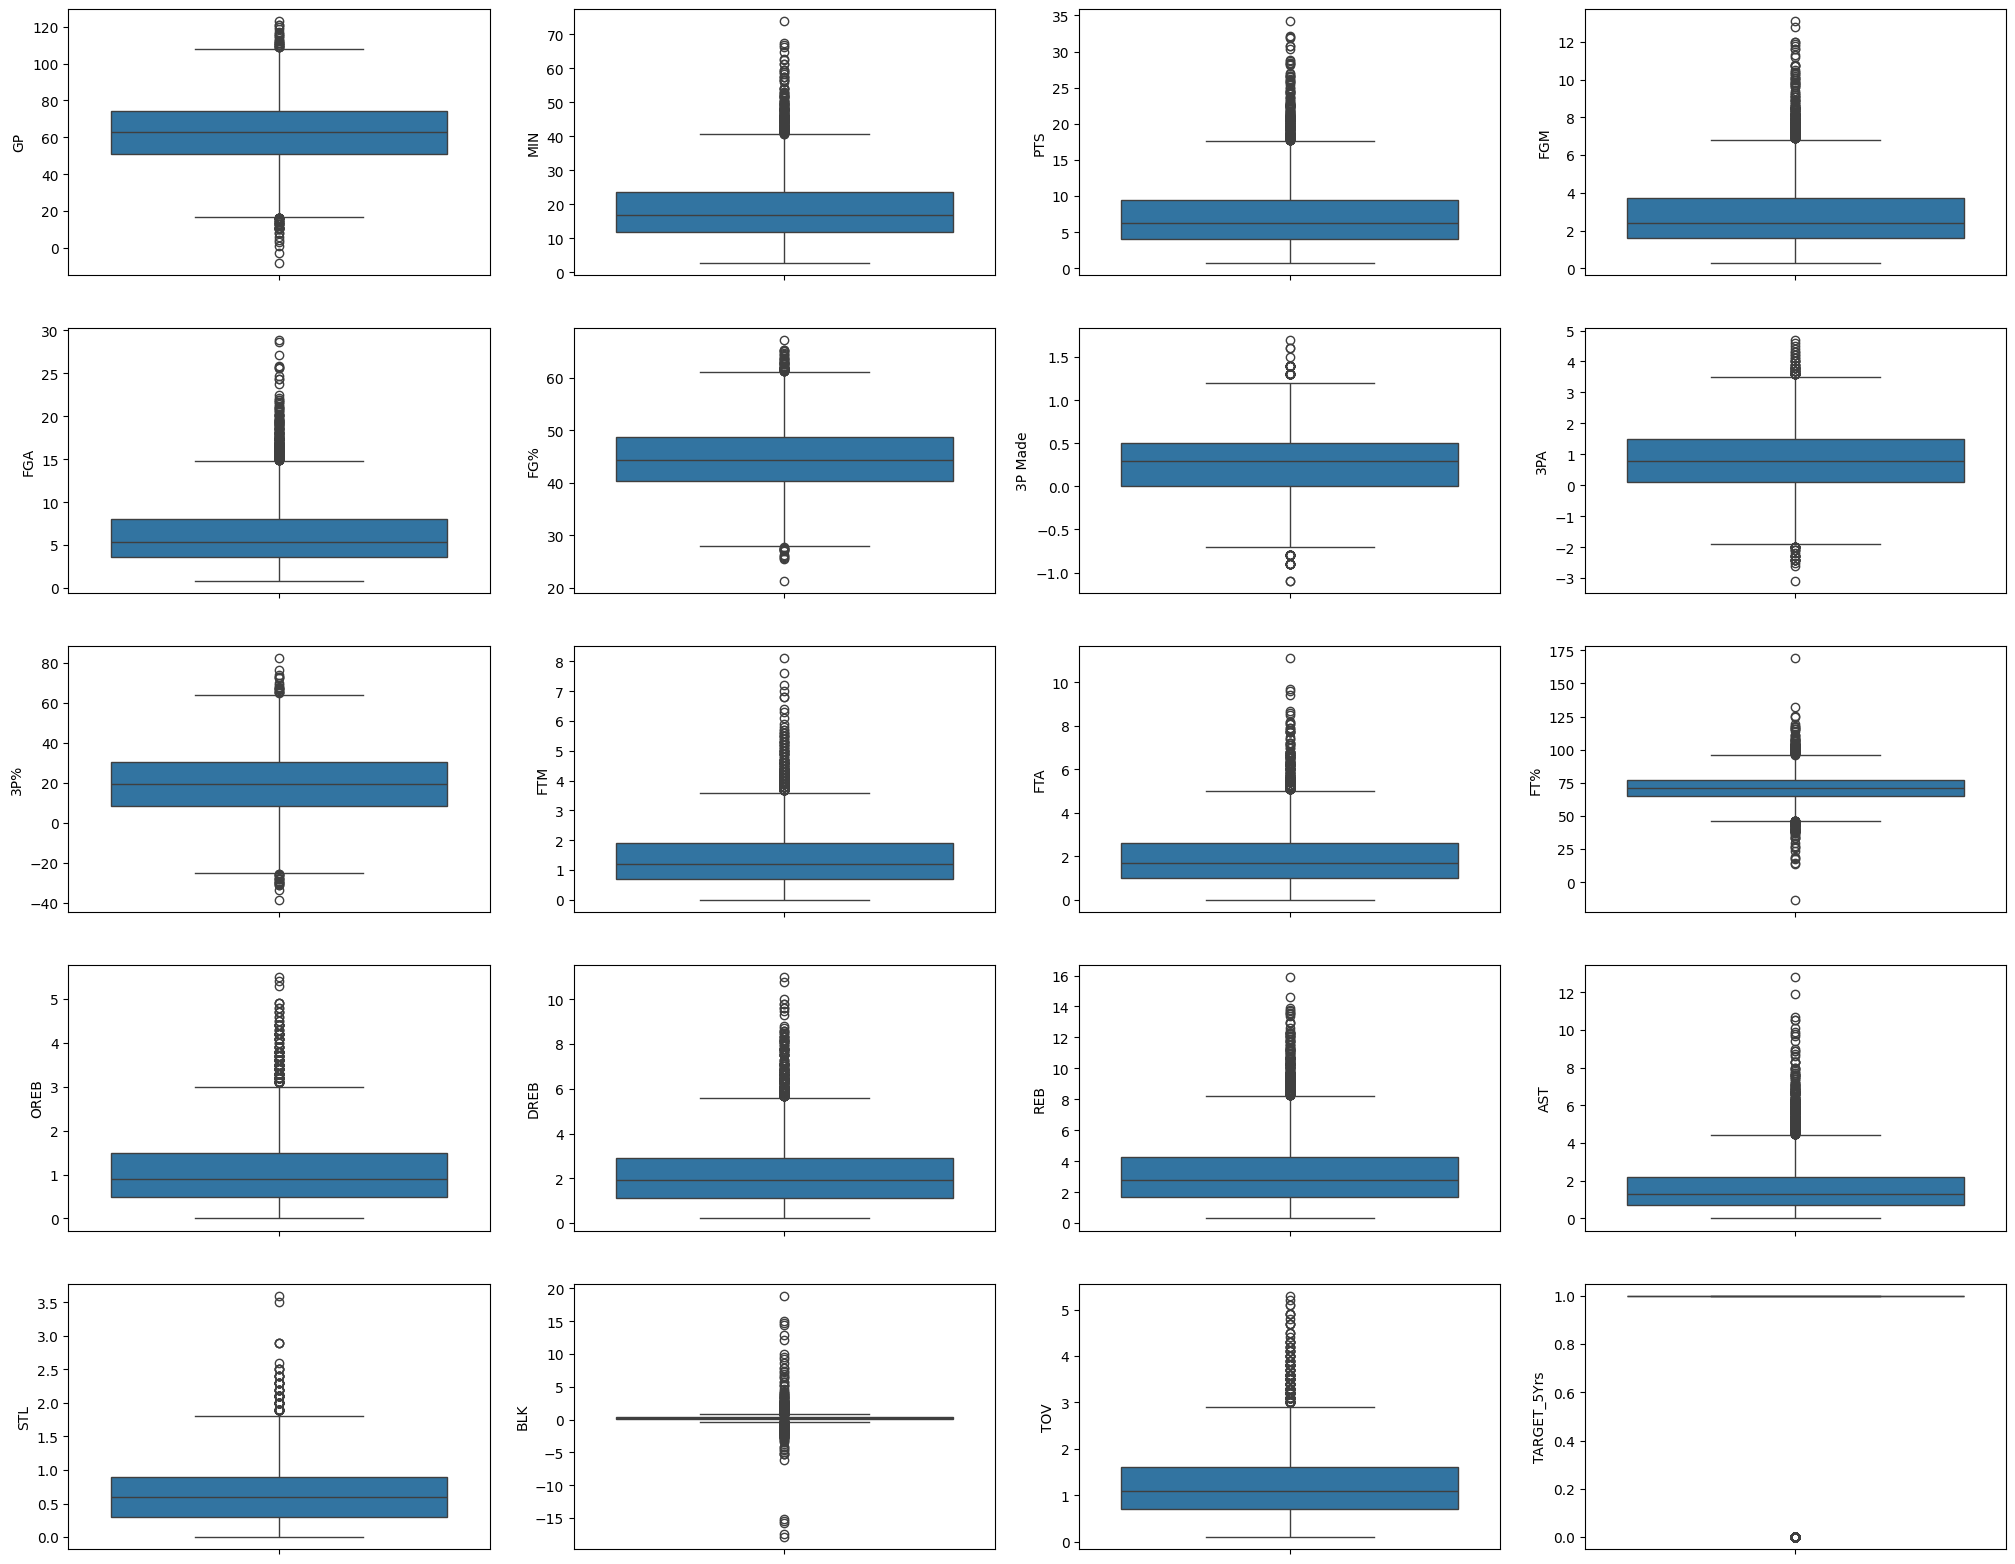

In [502]:
df=df.drop('Id',axis=1)

pos=1
plt.figure(figsize=(25,20))
for i in df.columns:
    plt.subplot(5,4,pos)
    sns.boxplot(data=df[i])
    pos+=1

An initial inspection of the descriptive statistics (df.describe()) and the boxplots for several key features reveals the presence of both impossible data errors and extreme, unrealistic outliers. Addressing these issues is mandatory before training any model. I have identified values that are physically or mathematically impossible within the context of NBA rookie statistics:


 - An NBA team plays a maximum of 82 regular season games, plus up to 28 playoff games (4 rounds of 7 games), meaning the absolute maximum is around 110. Any value exceeding this is a data entry error.

- Percentages in basketball (Field Goal, Three-Point, Free Throw) are mathematically constrained to a maximum of $100\%$
    
- Statistics like PTS, REB, AST, BLK, and TOV cannot be negative. Players cannot score $-5$ points or have $-2$ rebounds.

Beyond impossible errors, the data exhibits extreme statistical anomalies that, while theoretically possible, are highly unrealistic for a rookie and can severely skew model training, particularly for linear models.

For each suspicious statistical column, a reasonable maximum value must be determined based on historical NBA records for a rookie. The dataset is then filtered to eliminate all data points that exceed this defined maximum value for the respective column.

In [503]:
condition = df['MIN'] <= 46.4  #The record for more minutes per game played in a rookie season is 46.4 by Wilt Chamberlain at 1960


df2 = df[condition].copy()

df2

,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,80,24.3,7.8,3.0,6.4,45.7,0.1,0.3,22.6,2.0,2.9,72.1,2.2,2.0,3.8,3.2,1.1,0.2,1.6,1
1,75,21.8,10.5,4.2,7.9,55.1,-0.3,-1.0,34.9,2.4,3.6,67.8,3.6,3.7,6.6,0.7,0.5,0.6,1.4,1
2,85,19.1,4.5,1.9,4.5,42.8,0.4,1.2,34.3,0.4,0.6,75.7,0.6,1.8,2.4,0.8,0.4,0.2,0.6,1
3,63,19.1,8.2,3.5,6.7,52.5,0.3,0.8,23.7,0.9,1.5,66.9,0.8,2.0,3.0,1.8,0.4,0.1,1.9,1
4,63,17.8,3.7,1.7,3.4,50.8,0.5,1.4,13.7,0.2,0.5,54.0,2.4,2.7,4.9,0.4,0.4,0.6,0.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,32,9.2,1.8,0.7,1.8,40.3,-0.1,-0.2,23.1,0.4,0.6,65.7,0.3,1.8,1.9,0.5,0.3,0.2,0.4,1
7996,54,6.0,1.8,0.7,1.4,48.7,0.1,0.1,3.1,0.2,0.4,70.1,1.0,1.1,2.0,0.1,0.0,0.3,0.3,1
7997,85,28.2,10.7,4.0,9.0,45.1,0.2,0.6,23.6,2.8,3.9,69.7,1.0,2.1,3.1,3.4,1.2,0.2,1.8,1
7998,39,7.7,2.5,1.0,2.3,40.1,-0.3,-0.5,13.3,0.6,0.7,74.3,0.4,0.6,0.9,0.2,0.3,0.3,0.5,1


In [504]:
condition1 = df2['GP'] <= 104  #Record set by Jack Sikma at 1978
condition2 = df2['FT%'] <= 100  # Its impossible to have more than a 100% 
condition3 = df2['BLK'] <= 4.0  # Record set by Manute Bol at 1986
condition4 = df2['TOV'] <= 4.4  # Record set by Allen Iverson at 1997
condition5 = df2['STL'] <= 2.6 #Record set by Dudley Bradley at 1980

df3 = df2[condition1].copy()
df3 = df3[condition2].copy()
df3 = df3[condition3].copy()
df3 = df3[condition4].copy()
df3 = df3[condition5].copy()


C:\Users\Xavier\AppData\Local\Temp\ipykernel_32092\2050333342.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df3 = df3[condition2].copy()
C:\Users\Xavier\AppData\Local\Temp\ipykernel_32092\2050333342.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df3 = df3[condition3].copy()
C:\Users\Xavier\AppData\Local\Temp\ipykernel_32092\2050333342.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df3 = df3[condition4].copy()
C:\Users\Xavier\AppData\Local\Temp\ipykernel_32092\2050333342.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df3 = df3[condition5].copy()


In [505]:
positive_data = (df >= 0).all(axis=1) #All data must be positive

df4 = df3[positive_data].copy()

print ("We have",df4.shape[0],"rows and",df4.shape[1],"atributes")

We have 4802 rows and 20 atributes


C:\Users\Xavier\AppData\Local\Temp\ipykernel_32092\672251007.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df4 = df3[positive_data].copy()


In [506]:
df4.describe()


,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
count,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000
mean,64.094127,20.208372,7.963182,3.053915,6.844440,44.285693,0.411308,1.218846,23.818721,1.467701,2.034631,72.086422,1.065223,2.317118,3.387130,1.744252,0.698959,0.301562,1.332007,0.846731
std,16.047001,8.220255,4.077862,1.605844,3.416897,5.728751,0.281564,0.778417,12.942048,0.877324,1.176084,9.281555,0.682078,1.277005,1.869339,1.303537,0.394298,0.312143,0.699011,0.360285
min,3.000000,3.800000,0.900000,0.300000,0.900000,25.700000,0.000000,0.000000,-0.000000,0.000000,0.000000,37.900000,0.000000,0.200000,0.400000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,53.000000,14.000000,4.900000,1.800000,4.200000,40.400000,0.200000,0.600000,14.000000,0.800000,1.125000,66.100000,0.600000,1.400000,2.000000,0.800000,0.400000,0.100000,0.800000,1.000000
50%,64.000000,18.900000,7.300000,2.700000,6.200000,44.200000,0.400000,1.100000,23.000000,1.300000,1.800000,72.100000,0.900000,2.100000,3.000000,1.400000,0.600000,0.200000,1.200000,1.000000
75%,75.000000,25.500000,10.400000,4.000000,8.900000,48.100000,0.600000,1.700000,32.600000,2.000000,2.700000,77.875000,1.400000,3.000000,4.400000,2.400000,0.900000,0.400000,1.700000,1.000000
max,104.000000,46.400000,27.000000,11.200000,21.400000,67.200000,1.700000,4.700000,73.700000,7.000000,8.700000,99.900000,4.800000,10.000000,13.900000,9.000000,2.600000,4.000000,4.400000,1.000000


In [507]:
nans_in_columns = df4.isnull().sum()

print("Nans for each column ")
print(nans_in_columns)

Nans for each column 
GP             0
MIN            0
PTS            0
FGM            0
FGA            0
FG%            0
3P Made        0
3PA            0
3P%            0
FTM            0
FTA            0
FT%            0
OREB           0
DREB           0
REB            0
AST            0
STL            0
BLK            0
TOV            0
TARGET_5Yrs    0
dtype: int64


As a result of filtering out these erroneous entries, the dataset size was reduced from approximately 8,000 to 4,802 observations.

Despite this reduction, the decision to prioritize data quality over quantity is justified by the following points:

- No NaNs: Following the cleaning process, the dataset is completely "clean," meaning there are no missing values across any of the features. This allows for a more stable training process without the need for imputation techniques that might bias the results.

-  A sample of nearly 5,000 players remains a robust and substantial volume of data, providing more than enough statistical power to identify meaningful patterns and trends in rookie performance.

<Axes: >

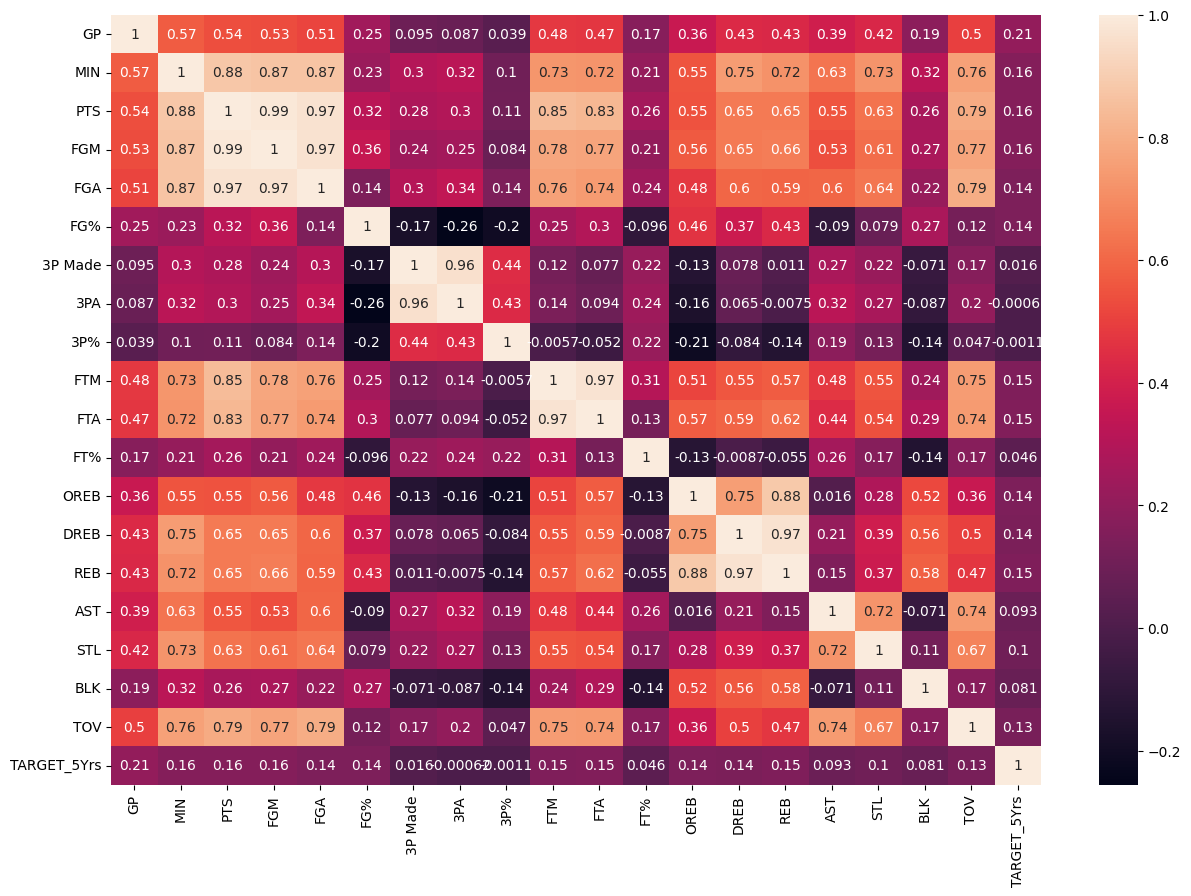

In [508]:
target= 'TARGET_5Yrs'

corr= df4[df4.columns].corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr,annot=True)

- Based on the results from the Correlation Matrix, I decided to apply Feature Engineering to simplify the dataset and avoid using variables that tell the same story twice. This process ensures the model doesn't get confused by redundant information and stays focused on the most important performance traits needed to predict a long NBA career.


- The correlation between TARGET_5Yrs and all the statistical features is positive. But no single variable exceeds a strong correlation. This confirms that career longevity is a multi-factorial prediction problem not only made by one stat.

- The highest correlations with the target are found in variables like GP (Games Played) and MIN (Minutes per Game). This means that if a rookie receives significant playing time and appears in many games, this is the most robust signal for a long career. Early career survival is determined more by coach's trust and opportunity than by pure shooting efficiency.

- Statistics related to three-point shooting exhibit the lowest correlations, suggesting that the ability to shoot the three has a nearly negligible individual impact on predicting career longevity for this specific dataset. The extremely low correlation of the three-point metrics suggests that the dataset likely spans an era where specialization in the three-point shot was not a primary driver for player retention in the league, unlike today's NBA



- Given the insights from the Correlation Matrix, we observe extremely high multicollinearity among the core offensive metrics. This redundancy, while logical in a basketball context, can lead to model instability and inefficient training. 

- To improve it, I  have decided to eliminate the volume statistics FGM and FGA from the training set.
This action is justified because by retaining PTS and FG%, we effectively keep all the necessary offensive information while simplifying the model:
    - PTS tells the model "How much did the player score?" 

    - FG% tells the model "How efficiently did the player score?"

- In addition to field goals, the same logic was applied to three-point and free-throw metrics to further reduce redundancy. Specifically, 3P Attempted (3PA) was removed due to its near-perfect correlation with 3P Made (3PM). By retaining 3P%, the model still accounts for the player's long-range accuracy without needing the redundant volume of attempts. Similarly, Free Throws Attempted (FTA) was eliminated for being highly collinear with Free Throws Made (FTM), as the scoring and efficiency (FT%) already capture the player's performance from the line.

- Regarding rebounding, Defensive Rebounds (DREB) were removed because they are nearly perfectly correlated with Total Rebounds (REB). However, Offensive Rebounds (OREB) were intentionally retained; they show a lower correlation with total rebounds and represent a specialized, high-effort skill the ability to secure the ball while at a positional disadvantage. 

In [509]:
df5=df4.drop('FGM',axis=1)
df5= df5.drop('FGA',axis=1)
df5=df5.drop('DREB', axis=1 )
df5=df5.drop('FTA', axis=1)
df5= df5.drop('3PA',axis=1)


print ("We have",df5.shape[0],"rows and",df5.shape[1],"atributes")

We have 4802 rows and 15 atributes


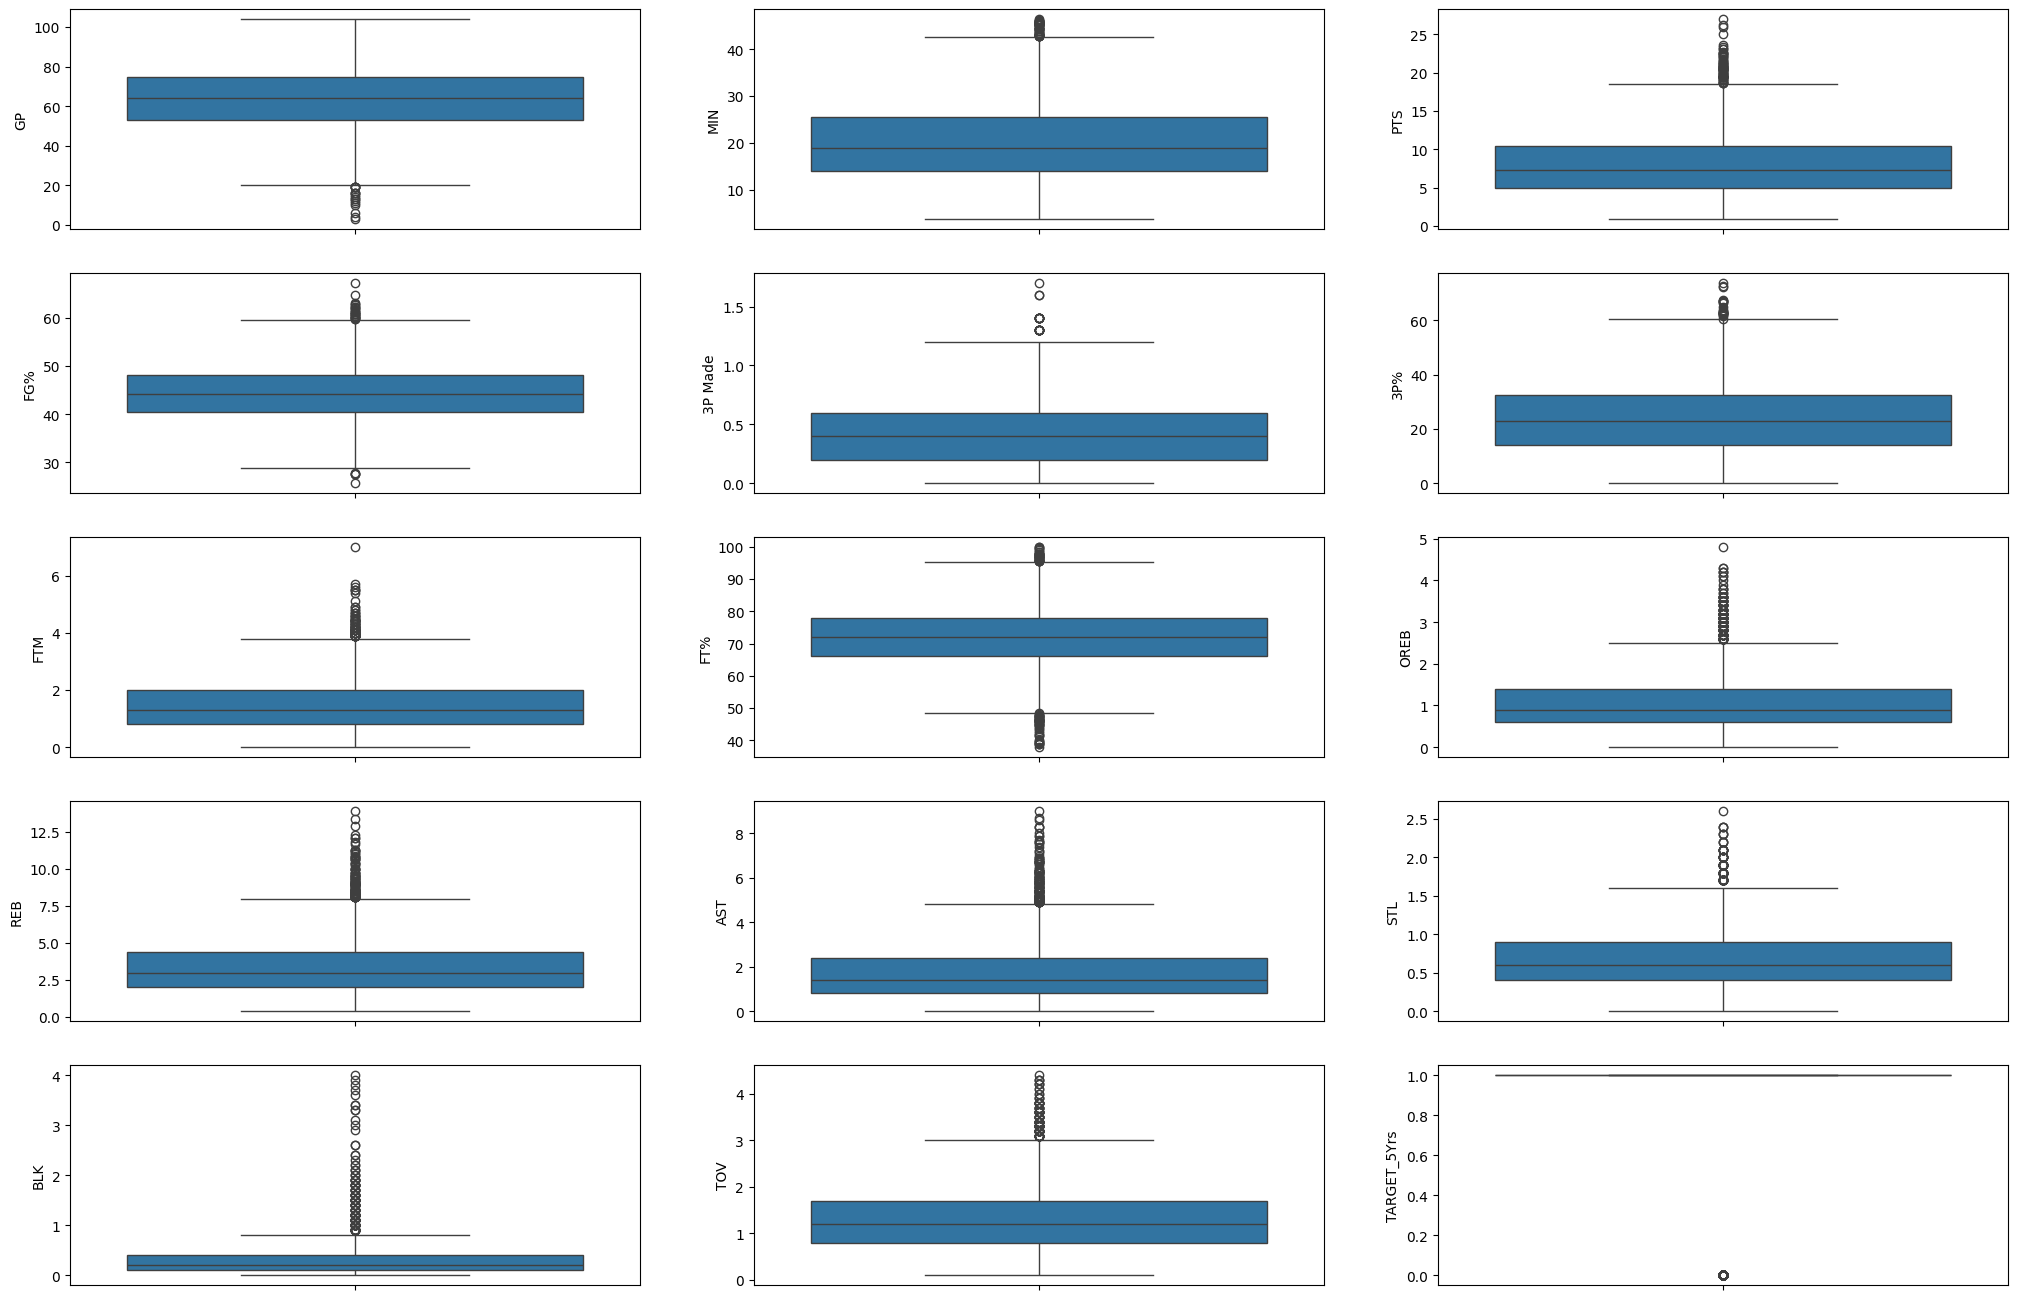

In [510]:
pos=1
plt.figure(figsize=(25,20))
for i in df5.columns:
    plt.subplot(6,3,pos)
    sns.boxplot(data=df5[i])
    pos+=1
    
    

Having already seen which attributes have the highest correlation with our target variable, we will now focus on the distribution of these variables.

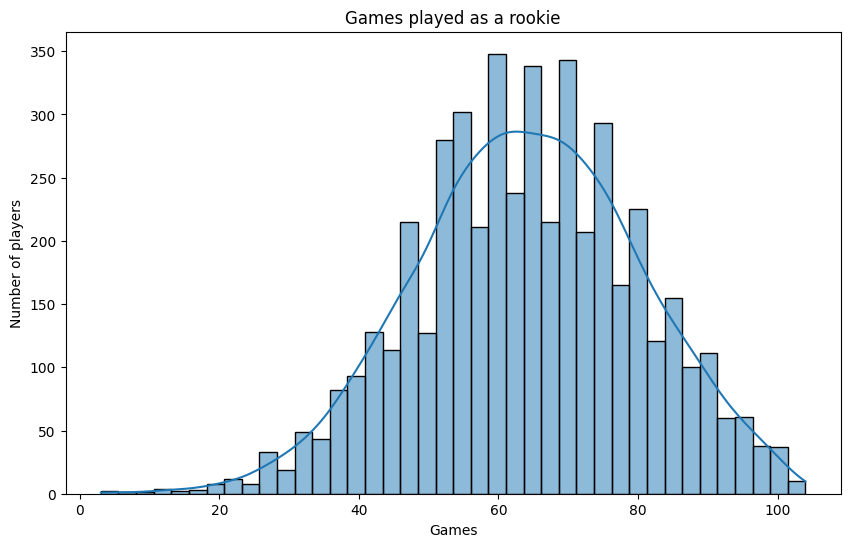

In [511]:
plt.figure(figsize=(10, 6))
sns.histplot(df5['GP'], bins=40, kde=True)
plt.title("Games played as a rookie")
plt.xlabel('Games')
plt.ylabel('Number of players')
plt.show()

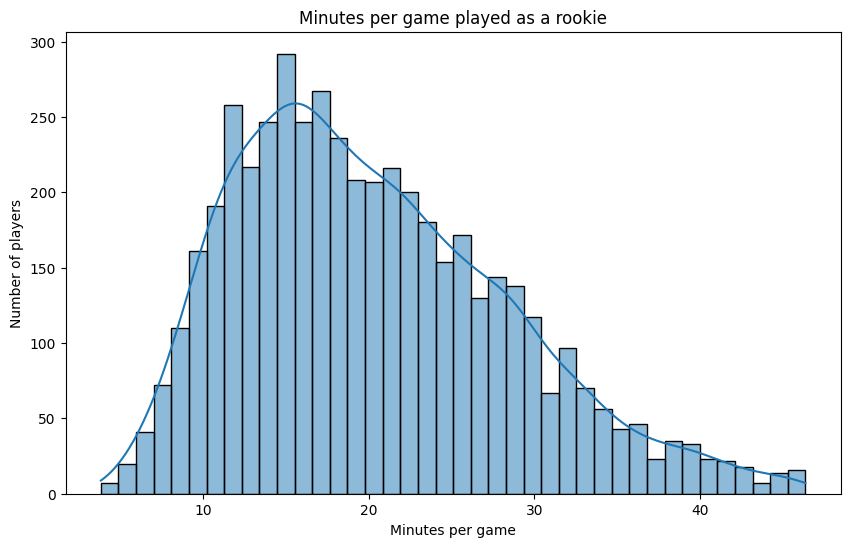

In [512]:
plt.figure(figsize=(10, 6))
sns.histplot(df5['MIN'], bins=40, kde=True)
plt.title("Minutes per game played as a rookie")
plt.xlabel('Minutes per game')
plt.ylabel('Number of players')
plt.show()

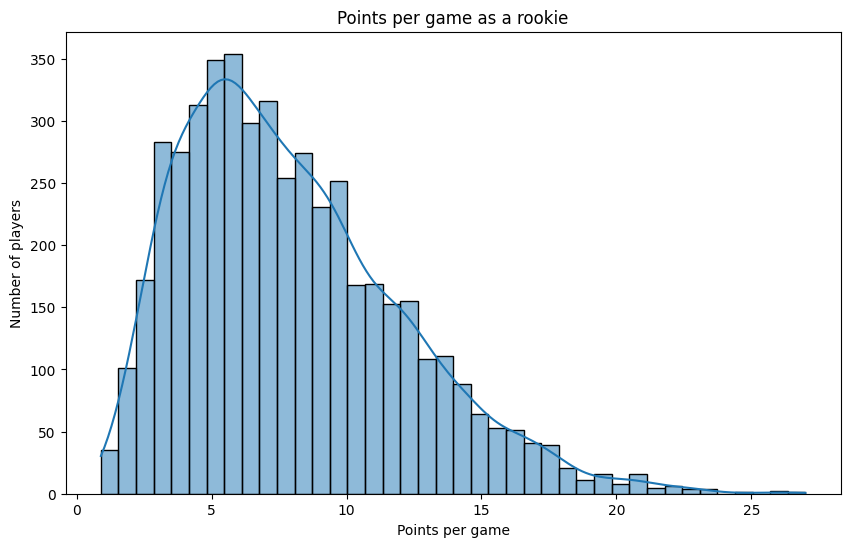

In [513]:
plt.figure(figsize=(10, 6))
sns.histplot(df5['PTS'], bins=40, kde=True)
plt.title("Points per game as a rookie")
plt.xlabel('Points per game')
plt.ylabel('Number of players')
plt.show()

It can be seen that it is normal for coaches to assign rookies minutes and include them in a high number of games (GP centered between 60 and 70). This practice is essential for two key reasons:

- Player Development: Rookies must be exposed to live NBA action to develop their skills, conditioning, and understanding of team schemes at the professional level.

- Talent Evaluation: Teams need a large sample size of performance data to accurately evaluate a rookie’s potential and determine whether to invest in their future contract.


Despite the need for development, the data shows that the majority of rookies operate in a bench role, which restricts their volume:

- Limited Minutes: The distribution for MIN peaks between 15 and 20 minutes per game. This is significantly below the standard starting role (30+ minutes), confirming that most players are rotational reserves learning without having a big role.

- Lower Scoring: Similarly, the PTS distribution peaks between 5 and 10 points per game. This lower production is logical because:

   - Skill Gap: Rookies often lack the maturity, strength, and system knowledge to immediately perform at a high level.

   - Learning Curve: They are still improving and adapting to the speed and complexity of the NBA game during their first year.

(array([0, 1]), [Text(0, 0, '1'), Text(1, 0, '0')])

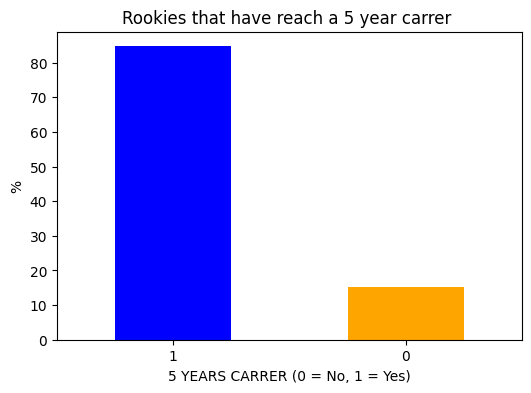

In [514]:
targetcount = df5[target].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = targetcount.plot(kind='bar', color=['blue', 'orange'])
plt.title('Rookies that have reach a 5 year carrer ')
plt.xlabel('5 YEARS CARRER (0 = No, 1 = Yes)')
plt.ylabel('%')
plt.xticks(rotation=0)

The bar chart visualizing the TARGET_5Yrs variable reveals a significant Class Imbalance that represents a critical challenge for the modeling phase. 

- Dominant Class: The majority class (1, or "5 Years Career = Yes") accounts for approximately 85% of the observations.

- Minority Class: The minority class (0, or "5 Years Career = No") accounts for only about 15% of the observations.


This imbalance is not merely a statistical anomaly but a reflection of the selection process and economic realities of the NBA. 

The high success rate is explained by the High Barrier to Entry into the league: By the time a player reaches the NBA, they are already among the top 0.01% of basketball talent worldwide. The selection process (draft, scouting, contracts) is highly efficient. Consequently, a player who secures an NBA rookie contract and receives enough playing time to enter this dataset is already a highly vetted prospect whose professional longevity is, statistically, the expected outcome.

In [515]:
analysis_by_target = df5.groupby('TARGET_5Yrs').mean()
display(analysis_by_target)

,GP,MIN,PTS,FG%,3P Made,3P%,FTM,FT%,OREB,REB,AST,STL,BLK,TOV
TARGET_5Yrs,,,,,,,,,,,,,,
0,56.222826,17.028533,6.402717,42.371060,0.400679,23.851495,1.156522,71.079484,0.833424,2.732609,1.460870,0.602853,0.242255,1.119022
1,65.518938,20.783965,8.245647,44.632268,0.413232,23.812789,1.524029,72.268692,1.107182,3.505607,1.795548,0.716355,0.312297,1.370561


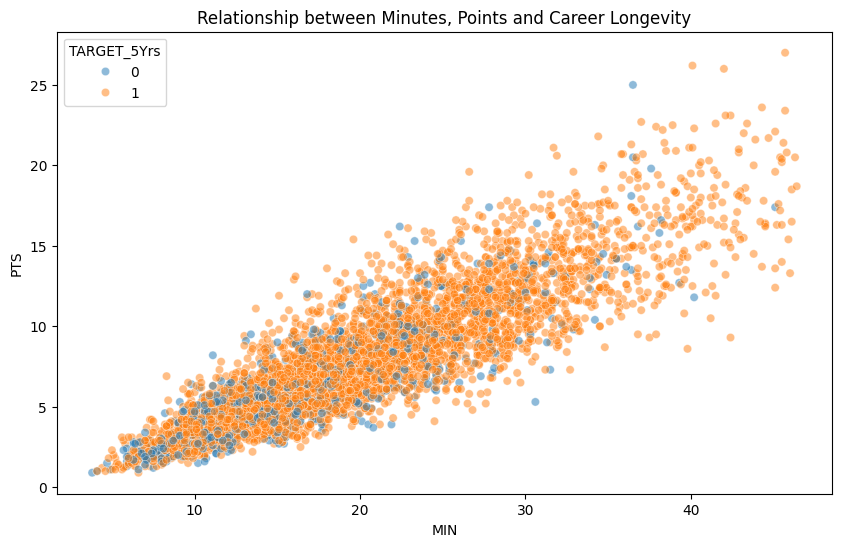

In [516]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df5, x='MIN', y='PTS', hue='TARGET_5Yrs', alpha=0.5)
plt.title('Relationship between Minutes, Points and Career Longevity')
plt.show()

There is a high concentration of orange dots (Target 1) in the upper-right section of the graph. As the majority of the players who average more than 25 minutes and 10 points reach the 5-year career mark.

 Players in the bottom-left (low minutes, low points) show a much higher mix of blue dots (Target 0). This proves that regardless of efficiency, if a player cannot earn more than 10-12 minutes of playing time, their professional longevity is at high risk.

# CLASIFICATION

In [517]:
X=df5.drop(target,axis=1)
y=df5[target]


In [518]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,random_state=42,train_size= 0.7) 
print("There are",Xtrain.shape[0],"samples in the training dataset and",Xtest.shape[0],"samples at the test dataset")
print("There are", Xtrain.shape[1],"features")

There are 3361 samples in the training dataset and 1441 samples at the test dataset
There are 14 features


As an initial step, a Decision Tree Classifier is implemented to evaluate the predictive capacity of the dataset regarding player longevity.

In [519]:
dt=DecisionTreeClassifier(random_state = 42)
dt.fit(Xtrain,ytrain)
ytrain_dt= dt.predict(Xtrain)


Accuracy: 74.18%
F1 Score: 84.72%
Recall:   84.51%


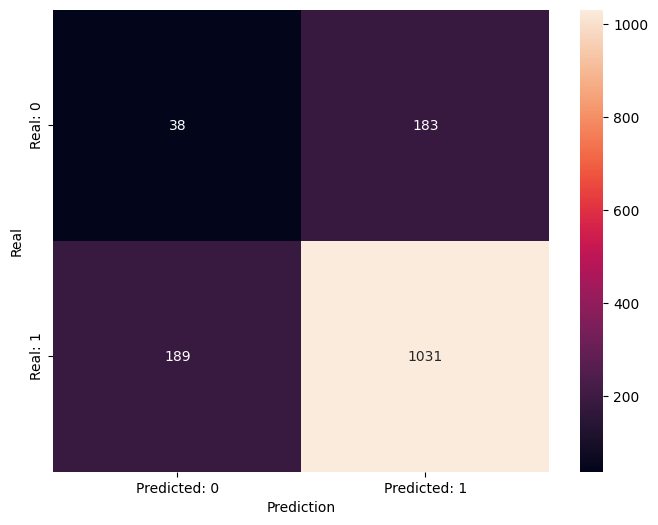

In [520]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

acc = accuracy_score(ytest, ytest_dt)
f1 = f1_score(ytest, ytest_dt)
recall = recall_score(ytest, ytest_dt)

print(f"Accuracy: {acc*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")
print(f"Recall:   {recall*100:.2f}%")

cm = confusion_matrix(ytest, ytest_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=["Predicted: 0", "Predicted: 1"], 
            yticklabels=['Real: 0', 'Real: 1'])
plt.xlabel('Prediction')
plt.ylabel('Real')

plt.show()


The analysis of the Confusion Matrix reveals critical insights into the model's performance that Accuracy alone fails to capture. While the overall accuracy might seem acceptable, the model suffers from a significant predictive bias.

- Strong Bias Toward the Majority Class: The model shows a pronounced tendency to predict the value 1 (indicating the player will last more than 5 years). Out of 1,441 total predictions, the model assigned class "1" in 1,214 cases (1,031 True Positives + 183 False Positives).

- Failure to Detect the "0" Class: The primary weakness lies in identifying players who do not reach the 5-year mark. The matrix shows that out of 221 actual "0" class players, the model only correctly identified 38 (True Negatives), while failing on 183 of them (False Positives).

In [521]:
from matplotlib import pyplot
from sklearn.tree import plot_tree
from matplotlib.pyplot import figure

figure(figsize=(15,15))
plot_tree(model, filled=True,
    feature_names = ["GP", "MIN", "PTS", "FG%","3P Made","3P%","FTM","FT%","OREB","REB","AST","STL","BLK","TOV"],
    class_names = ["0", "1"],
    rounded = True,
    proportion = True)

InvalidParameterError: The 'decision_tree' parameter of plot_tree must be an instance of 'sklearn.tree._classes.DecisionTreeClassifier' or an instance of 'sklearn.tree._classes.DecisionTreeRegressor'. Got {'name': 'Random forest       ', 'estimator': RandomForestClassifier(max_depth=9, n_estimators=50, random_state=42), 'param': [{'max_depth': [4, 5, 6, 7, 8, 9], 'n_estimators': [10, 20, 30, 40, 50]}]} instead.

<Figure size 1500x1500 with 0 Axes>

To further improve the model's performance and address the bias revealed by the confusion matrix, the next steps will involve exploring more sophisticated algorithms and fine-tuning their settings.

The following models will be implemented and compared:

- Decision Tree (dt): Used as the baseline for interpretability.

- Gaussian Naive Bayes (nb): A probabilistic approach based on Bayes' theorem.

- Linear Perceptron (lp): A simple linear binary classifier that lays the foundation for neural networks.


- K-Nearest Neighbours (knn): A distance-based algorithm that classifies players based on their similarity to others in the dataset.

- AdaBoost (adb): An ensemble technique that focuses on correcting the errors of previous weak learners.

- Random Forest (rf): An ensemble of decision trees designed to improve predictive accuracy and control over-fitting.


By running this diverse suite of classifiers, it will be possible to identify which architecture provides the best balance between overall accuracy and the ability to correctly identify the minority class (players with careers shorter than five years). To ensure each model reaches its full potential, GridSearchCV will be applied to optimize the hyperparameters for each of these labels.


In [522]:
scores = ['accuracy'
        ,'precision_macro'
        , 'precision_weighted'
        , 'recall_macro'
        , 'f1_macro'
        , 'f1_weighted'
        ]

results = pd.DataFrame(columns=['scoring','model','best_params'
                                , 'accuracy','precision_macro'
        , 'precision_weighted'
        , 'recall_macro'
       ,'recall weighted'
        , 'f1_macro'
        , 'f1_weighted'
        ])


random_state=42
models = {
    'dt': {'name': 'Decision Tree       ',
           'estimator': DecisionTreeClassifier(random_state=random_state), 
           'param': [{'max_depth': [*range(1,20)],'class_weight':[None,'balanced']}],
          },
    'nb': {'name': 'Gaussian Naive Bayes',
           'estimator': GaussianNB(),
           'param': [{'var_smoothing': [10**exp for exp in range(-3,-13,-1)]}]
          },
    'lp': {'name': 'Linear Perceptron   ',
           'estimator': Perceptron(random_state=random_state),
           'param': [{'early_stopping': [True,False],'class_weight':[None,'balanced']}],
          },
    

    'knn':{'name': 'K Nearest Neighbor ',
           'estimator': KNeighborsClassifier(),
           'param': [{'n_neighbors': list(range(1,7))}]
       },
    'adb':{'name': 'AdaBoost           ',
           'estimator': AdaBoostClassifier(random_state=random_state),
           'param': [{'n_estimators':[10,20,30,40,50]
                     ,'learning_rate':[0.2,0.5,0.75,1,1.25,1.5]}]
          },
    'rf': {'name': 'Random forest       ',
           'estimator': RandomForestClassifier(random_state=random_state),
           'param': [{'max_depth': [*range(4,10)]
                     ,'n_estimators':[*range(10,60,10)]}]
          }

}

In [523]:
cv = StratifiedKFold(n_splits = 3, random_state = 42, shuffle = True)
clfs=[]
y_preds=[]

for score in scores:
    for key, model in models.items(): 
        clf = GridSearchCV(
            estimator=model['estimator'],
            param_grid=model['param'],
            scoring = score,
            cv = cv)
        clf.fit(Xtrain, ytrain)
        y_pred = clf.predict(Xtest)
        clfs.append(clf)
        y_preds.append(y_pred)
        cr = classification_report(ytest, y_pred,output_dict=True)
        results.loc[len(results)]= [
            score,
            model['name'],
            clf.best_params_,
            cr['accuracy'],
            cr['macro avg']['precision'],
            cr['weighted avg']['precision'],
            cr['macro avg']['recall'],
            cr['weighted avg']['recall'],
            cr['macro avg']['f1-score'],
            cr['weighted avg']['f1-score']
        ]
        print(model['name'], "done")
    print(score, "done")
    

Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done
AdaBoost            done
Random forest        done
accuracy done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done
AdaBoost            done
Random forest        done
precision_macro done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done
AdaBoost            done
Random forest        done
precision_weighted done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done
AdaBoost            done
Random forest        done
recall_macro done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done
AdaBoost            done
Random forest        done
f1_macro done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done
AdaBoost            done
Random fore

In [524]:
for score in scores:
    print ("results for scoring", score)
    mask = (results['scoring'] == score)    
    results2 = results[mask].copy()
    display(results2.sort_values(by=score, ascending=False))

results for scoring accuracy


,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
0,accuracy,Decision Tree,"{'class_weight': None, 'max_depth': 1}",0.846634,0.423317,0.716790,0.500000,0.846634,0.458474,0.776320
4,accuracy,AdaBoost,"{'learning_rate': 0.5, 'n_estimators': 20}",0.846634,0.423317,0.716790,0.500000,0.846634,0.458474,0.776320
5,accuracy,Random forest,"{'max_depth': 4, 'n_estimators': 20}",0.846634,0.423317,0.716790,0.500000,0.846634,0.458474,0.776320
2,accuracy,Linear Perceptron,"{'class_weight': None, 'early_stopping': True}",0.845940,0.590172,0.768229,0.501443,0.845940,0.462704,0.777292
3,accuracy,K Nearest Neighbor,{'n_neighbors': 5},0.820264,0.535276,0.753439,0.512215,0.820264,0.501961,0.777989
1,accuracy,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.687023,0.560396,0.784290,0.598409,0.687023,0.556375,0.723277


results for scoring precision_macro


,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
8,precision_macro,Linear Perceptron,"{'class_weight': None, 'early_stopping': True}",0.845940,0.590172,0.768229,0.501443,0.845940,0.462704,0.777292
7,precision_macro,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.687023,0.560396,0.784290,0.598409,0.687023,0.556375,0.723277
6,precision_macro,Decision Tree,"{'class_weight': 'balanced', 'max_depth': 2}",0.498265,0.557334,0.804237,0.607353,0.498265,0.460766,0.559348
9,precision_macro,K Nearest Neighbor,{'n_neighbors': 5},0.820264,0.535276,0.753439,0.512215,0.820264,0.501961,0.777989
10,precision_macro,AdaBoost,"{'learning_rate': 0.5, 'n_estimators': 20}",0.846634,0.423317,0.716790,0.500000,0.846634,0.458474,0.776320
11,precision_macro,Random forest,"{'max_depth': 6, 'n_estimators': 50}",0.845246,0.423211,0.716609,0.499180,0.845246,0.458067,0.775630


results for scoring precision_weighted


...

,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
18,recall_macro,Decision Tree,"{'class_weight': 'balanced', 'max_depth': 2}",0.498265,0.557334,0.804237,0.607353,0.498265,0.460766,0.559348
19,recall_macro,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.687023,0.560396,0.784290,0.598409,0.687023,0.556375,0.723277
21,recall_macro,K Nearest Neighbor,{'n_neighbors': 2},0.696738,0.543483,0.769631,0.565242,0.696738,0.541770,0.726512
22,recall_macro,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.836919,0.583411,0.768945,0.516494,0.836919,0.501536,0.784994
20,recall_macro,Linear Perceptron,"{'class_weight': 'balanced', 'early_stopping':...",0.834837,0.566133,0.763077,0.513411,0.834837,0.496922,0.782762
23,recall_macro,Random forest,"{'max_depth': 8, 'n_estimators': 20}",0.843858,0.423104,0.716428,0.498361,0.843858,0.457659,0.774940


results for scoring f1_macro


,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
25,f1_macro,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.687023,0.560396,0.784290,0.598409,0.687023,0.556375,0.723277
27,f1_macro,K Nearest Neighbor,{'n_neighbors': 6},0.814712,0.565186,0.766703,0.533021,0.814712,0.534518,0.784888
24,f1_macro,Decision Tree,"{'class_weight': None, 'max_depth': 13}",0.785566,0.527492,0.752658,0.519513,0.785566,0.519821,0.767469
28,f1_macro,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.836919,0.583411,0.768945,0.516494,0.836919,0.501536,0.784994
26,f1_macro,Linear Perceptron,"{'class_weight': None, 'early_stopping': True}",0.845940,0.590172,0.768229,0.501443,0.845940,0.462704,0.777292
29,f1_macro,Random forest,"{'max_depth': 8, 'n_estimators': 20}",0.843858,0.423104,0.716428,0.498361,0.843858,0.457659,0.774940


results for scoring f1_weighted


,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
34,f1_weighted,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.836919,0.583411,0.768945,0.516494,0.836919,0.501536,0.784994
33,f1_weighted,K Nearest Neighbor,{'n_neighbors': 6},0.814712,0.565186,0.766703,0.533021,0.814712,0.534518,0.784888
32,f1_weighted,Linear Perceptron,"{'class_weight': None, 'early_stopping': True}",0.845940,0.590172,0.768229,0.501443,0.845940,0.462704,0.777292
30,f1_weighted,Decision Tree,"{'class_weight': None, 'max_depth': 3}",0.845246,0.423211,0.716609,0.499180,0.845246,0.458067,0.775630
35,f1_weighted,Random forest,"{'max_depth': 8, 'n_estimators': 20}",0.843858,0.423104,0.716428,0.498361,0.843858,0.457659,0.774940
31,f1_weighted,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.687023,0.560396,0.784290,0.598409,0.687023,0.556375,0.723277


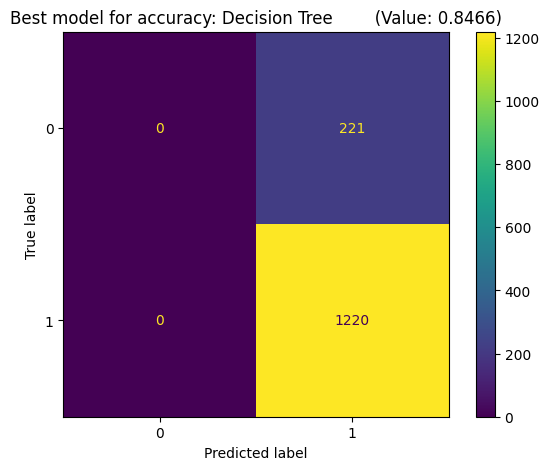

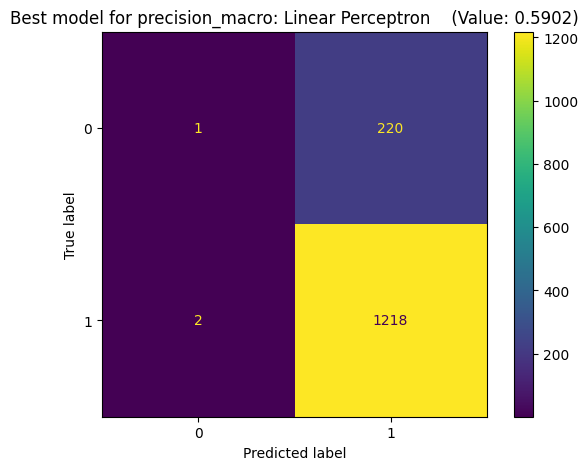

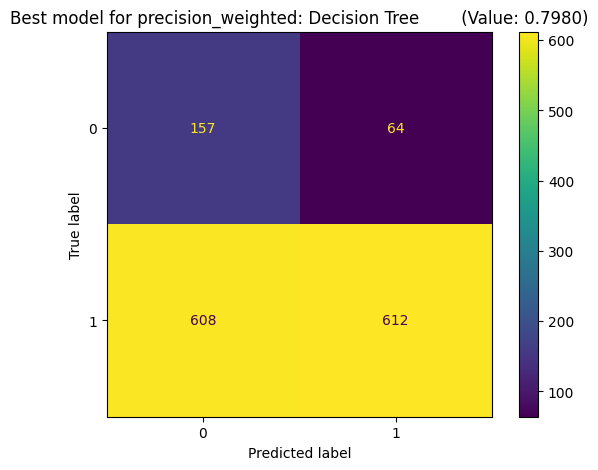

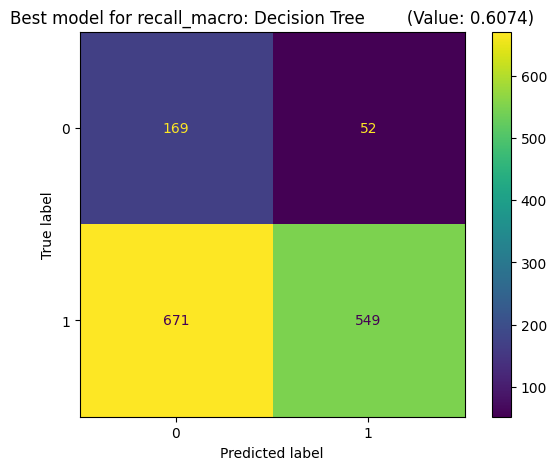

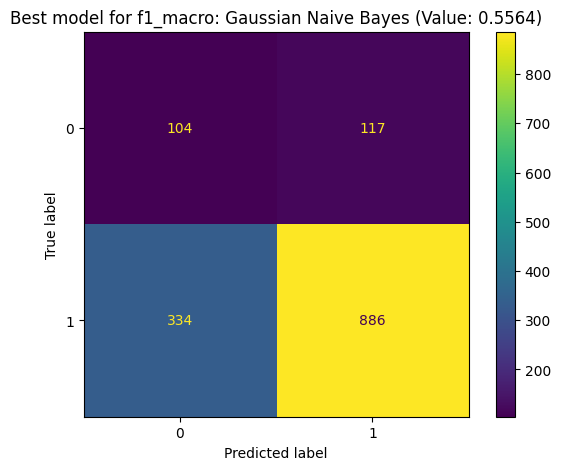

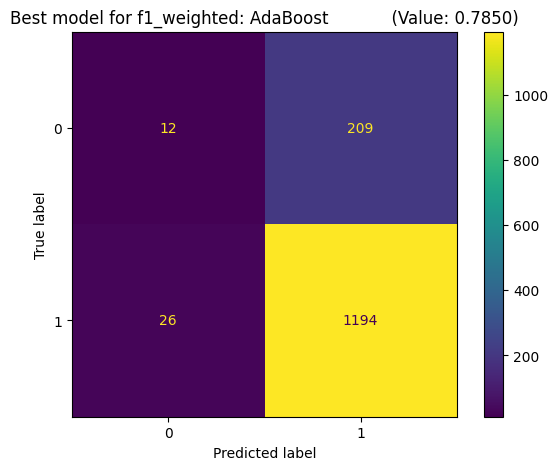

In [525]:
for score in scores:

    filter_score = results[results['scoring'] == score]
    best_row_index = filter_score[score].idxmax()
    best_model_name = results.loc[best_row_index, 'model']
    best_estimator = clfs[best_row_index]
    
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay.from_estimator(
        estimator=best_estimator,
        X=Xtest,
        y=ytest,
        ax=ax,
    )
    
    title = f"Best model for {score}: {best_model_name} (Value: {results.loc[best_row_index, score]:.4f})"
    ax.set_title(title)
    plt.show()

After evaluating multiple classifiers, the Gaussian Naive Bayes model was selected as the optimal choice, despite having a lower overall accuracy than the Decision Tree or AdaBoost.

The primary reason for this decision is the class imbalance. Models optimized for Accuracy or Weighted F1 tend to "cheat" by predicting the majority class for almost every player. For instance, the AdaBoost model (f1_weighted: 0.7850) only detected 12 failures, while the Decision Tree (accuracy: 0.8466) detected 0. These models are effectively blind to the minority class.

In contrast, the Gaussian Naive Bayes (optimized for f1_macro) provides the most balanced results:

- Identification of Risk: It correctly identified 104 true negatives, significantly outperforming the other models in detecting players who will not last 5 years in the league.

- Metric Reliability: The Macro F1-Score (0.5564) ensures that the performance on the minority class is given equal weight, providing a much more honest assessment of the model's predictive power.

In our dataset, variables like GP (Games Played) range from 0 to 82, while others like STL (Steals) or BLK (Blocks) have much smaller decimal values. To prevent the SVM from being biased toward high-magnitude features, we apply MinMaxScaler. This technique transforms all features into a fixed range, typically [0, 1], preserving the relative relationships between data points while ensuring "numerical equality."

--- Classification Report (SVM Balanced) ---
              precision    recall  f1-score   support

           0       0.23      0.64      0.34       221
           1       0.90      0.62      0.73      1220

    accuracy                           0.62      1441
   macro avg       0.57      0.63      0.54      1441
weighted avg       0.80      0.62      0.67      1441



Text(0.5, 1.0, 'SVM with Class Weight Balanced')

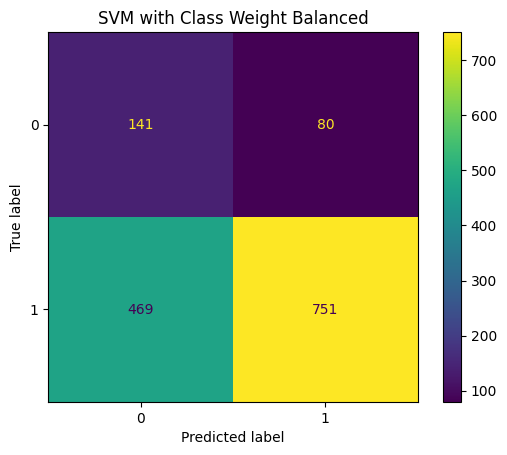

In [526]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(Xtrain)
X_test_scaled = scaler.transform(Xtest)

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True)
svm_model.fit(X_train_scaled, ytrain)
y_pred_svm = svm_model.predict(X_test_scaled)

print("--- Classification Report (SVM Balanced) ---")
print(classification_report(ytest, y_pred_svm))

disp = ConfusionMatrixDisplay.from_estimator(
    svm_model, X_test_scaled, ytest, 
    display_labels=['0', '1'], 
)
disp.ax_.set_title("SVM with Class Weight Balanced")

Unlike the Decision Tree or AdaBoost, which achieved high scores by simply predicting "Success" for every player, the SVM is the most effective model for identifying future bad players. It correctly found 141 True Negatives, significantly outperforming the Gaussian Naive Bayes (104) and the AdaBoost (12). The SVM produced only 80 False Positives (players predicted to succeed who actually failed), whereas the Gaussian Naive Bayes had 117. All of that increasing the Macro F1-Score. This proves that the model is honestly trying to learn the minority class rather than just guessing based on the 85% majority.


Despite being the best at catching failures, the SVM has significant drawbacks compared to the Gaussian Naive Bayes:

- Extreme Pessimism: The SVM produced 469 False Negatives, while the Gaussian Naive Bayes only produced 334. This means the SVM is much more likely to "reject" a good player. It is so afraid of failure that it misses out on nearly 40% of the legitimate talent in the dataset.

- Lower accuracy at class 0: Because the SVM flags so many players as risks, its precision for the "Failure" class is very low (0.23). In a practical scenario, scouts might stop trusting the model because it marks too many good players as bad.

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(Xtrain, ytrain)

results_smote = pd.DataFrame(columns=['scoring','model','best_params'
                                , 'accuracy','precision_macro'
        , 'precision_weighted'
        , 'recall_macro'
       ,'recall weighted'
        , 'f1_macro'
        , 'f1_weighted'
        ])


cv = StratifiedKFold(n_splits = 3, random_state = 42, shuffle = True)

for score in scores:
    for key, model in models.items(): 
        clf = GridSearchCV(
            estimator=model['estimator'],
            param_grid=model['param'],
            scoring = score,
            cv = cv)
        clf.fit(X_train_smote, y_train_smote)
        y_pred = clf.predict(Xtest)
        cr = classification_report(ytest, y_pred,output_dict=True)
        results_smote.loc[len(results_smote)]= [
            score,
            model['name'],
            clf.best_params_,
            cr['accuracy'],
            cr['macro avg']['precision'],
            cr['weighted avg']['precision'],
            cr['macro avg']['recall'],
            cr['weighted avg']['recall'],
            cr['macro avg']['f1-score'],
            cr['weighted avg']['f1-score']
        ]
        print(model['name'], "done")
    print(score, "done")

Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done


c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users

AdaBoost            done
Random forest        done
accuracy done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done


c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users

AdaBoost            done
Random forest        done
precision_macro done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done


...

AdaBoost            done
Random forest        done
recall_macro done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done


c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users

AdaBoost            done
Random forest        done
f1_macro done
Decision Tree        done
Gaussian Naive Bayes done
Linear Perceptron    done
K Nearest Neighbor  done


c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users

AdaBoost            done
Random forest        done
f1_weighted done


In [ ]:
for score in scores:
    print ("results for scoring", score)
    mask = (results_smote['scoring'] == score)    
    results_smote2 = results_smote[mask].copy()
    display(results_smote2.sort_values(by=score, ascending=False))

results for scoring accuracy


,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
4,accuracy,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.809160,0.538157,0.755613,0.518626,0.809160,0.515317,0.776948
2,accuracy,Linear Perceptron,"{'class_weight': 'balanced', 'early_stopping':...",0.778626,0.531111,0.754882,0.524677,0.778626,0.525995,0.765898
5,accuracy,Random forest,"{'max_depth': 9, 'n_estimators': 50}",0.747398,0.543018,0.764226,0.548845,0.747398,0.545063,0.755398
0,accuracy,Decision Tree,"{'class_weight': None, 'max_depth': 17}",0.716169,0.527653,0.757041,0.535960,0.716169,0.527893,0.734583
3,accuracy,K Nearest Neighbor,{'n_neighbors': 1},0.707842,0.536739,0.763740,0.551421,0.707842,0.536583,0.731888
1,accuracy,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.532963,0.556059,0.798932,0.607466,0.532963,0.481997,0.594641


results for scoring precision_macro


,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
7,precision_macro,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.532963,0.556059,0.798932,0.607466,0.532963,0.481997,0.594641
11,precision_macro,Random forest,"{'max_depth': 9, 'n_estimators': 50}",0.747398,0.543018,0.764226,0.548845,0.747398,0.545063,0.755398
10,precision_macro,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.809160,0.538157,0.755613,0.518626,0.809160,0.515317,0.776948
9,precision_macro,K Nearest Neighbor,{'n_neighbors': 1},0.707842,0.536739,0.763740,0.551421,0.707842,0.536583,0.731888
8,precision_macro,Linear Perceptron,"{'class_weight': None, 'early_stopping': False}",0.778626,0.531111,0.754882,0.524677,0.778626,0.525995,0.765898
6,precision_macro,Decision Tree,"{'class_weight': None, 'max_depth': 17}",0.716169,0.527653,0.757041,0.535960,0.716169,0.527893,0.734583


results for scoring precision_weighted


...

,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
19,recall_macro,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.532963,0.556059,0.798932,0.607466,0.532963,0.481997,0.594641
21,recall_macro,K Nearest Neighbor,{'n_neighbors': 1},0.707842,0.536739,0.763740,0.551421,0.707842,0.536583,0.731888
23,recall_macro,Random forest,"{'max_depth': 9, 'n_estimators': 50}",0.747398,0.543018,0.764226,0.548845,0.747398,0.545063,0.755398
18,recall_macro,Decision Tree,"{'class_weight': None, 'max_depth': 17}",0.716169,0.527653,0.757041,0.535960,0.716169,0.527893,0.734583
20,recall_macro,Linear Perceptron,"{'class_weight': 'balanced', 'early_stopping':...",0.778626,0.531111,0.754882,0.524677,0.778626,0.525995,0.765898
22,recall_macro,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.809160,0.538157,0.755613,0.518626,0.809160,0.515317,0.776948


results for scoring f1_macro


,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
29,f1_macro,Random forest,"{'max_depth': 9, 'n_estimators': 50}",0.747398,0.543018,0.764226,0.548845,0.747398,0.545063,0.755398
27,f1_macro,K Nearest Neighbor,{'n_neighbors': 1},0.707842,0.536739,0.763740,0.551421,0.707842,0.536583,0.731888
24,f1_macro,Decision Tree,"{'class_weight': None, 'max_depth': 17}",0.716169,0.527653,0.757041,0.535960,0.716169,0.527893,0.734583
26,f1_macro,Linear Perceptron,"{'class_weight': 'balanced', 'early_stopping':...",0.778626,0.531111,0.754882,0.524677,0.778626,0.525995,0.765898
28,f1_macro,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.809160,0.538157,0.755613,0.518626,0.809160,0.515317,0.776948
25,f1_macro,Gaussian Naive Bayes,{'var_smoothing': 1e-05},0.534351,0.555481,0.798114,0.606433,0.534351,0.482533,0.596056


results for scoring f1_weighted


,scoring,model,best_params,accuracy,precision_macro,precision_weighted,recall_macro,recall weighted,f1_macro,f1_weighted
34,f1_weighted,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.809160,0.538157,0.755613,0.518626,0.809160,0.515317,0.776948
32,f1_weighted,Linear Perceptron,"{'class_weight': 'balanced', 'early_stopping':...",0.778626,0.531111,0.754882,0.524677,0.778626,0.525995,0.765898
35,f1_weighted,Random forest,"{'max_depth': 9, 'n_estimators': 50}",0.747398,0.543018,0.764226,0.548845,0.747398,0.545063,0.755398
30,f1_weighted,Decision Tree,"{'class_weight': None, 'max_depth': 17}",0.716169,0.527653,0.757041,0.535960,0.716169,0.527893,0.734583
33,f1_weighted,K Nearest Neighbor,{'n_neighbors': 1},0.707842,0.536739,0.763740,0.551421,0.707842,0.536583,0.731888
31,f1_weighted,Gaussian Naive Bayes,{'var_smoothing': 1e-05},0.534351,0.555481,0.798114,0.606433,0.534351,0.482533,0.596056


c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


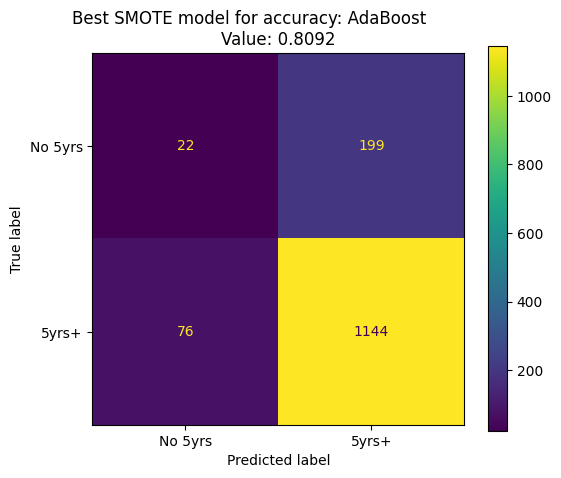

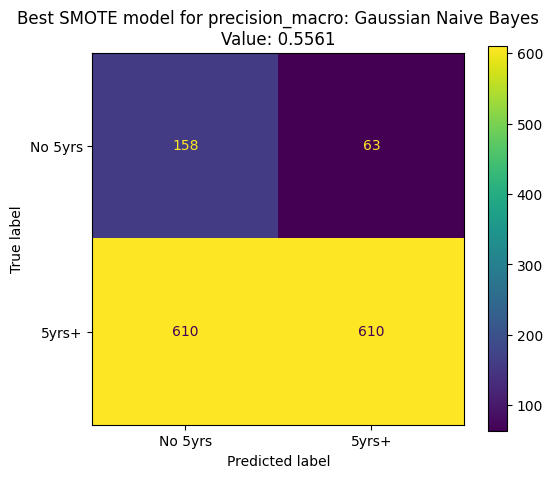

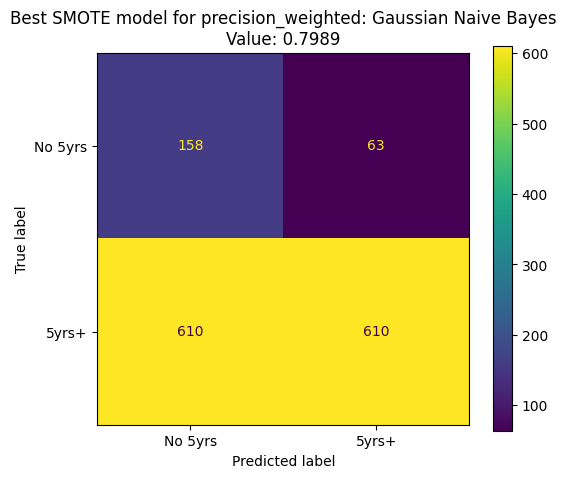

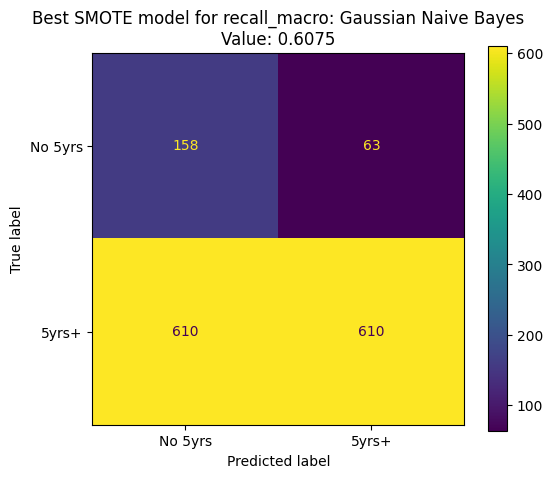

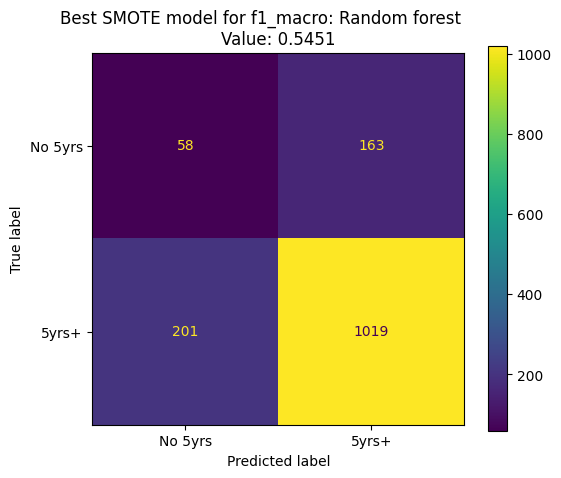

c:\Users\Xavier\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


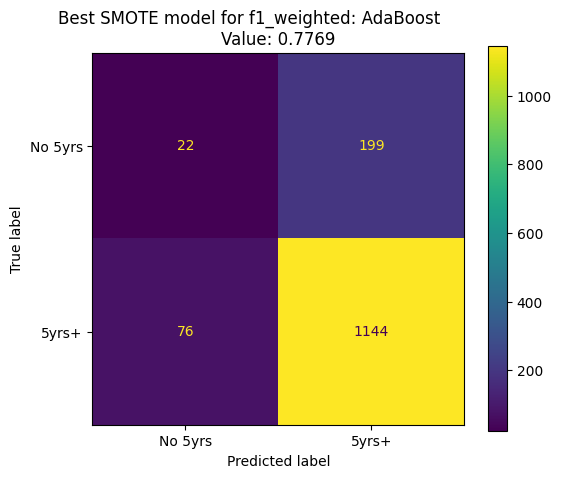

In [ ]:

for score in scores:
    best_row_index = results_smote[results_smote['scoring'] == score][score].idxmax()
    best_model_name = results_smote.loc[best_row_index, 'model']
    best_params = results_smote.loc[best_row_index, 'best_params']
    base_estimator = None
    for key, m in models.items():
        if m['name'] == best_model_name:
            base_estimator = m['estimator']
            break
            
    best_clf = base_estimator.set_params(**best_params)
    best_clf.fit(X_train_smote, y_train_smote)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay.from_estimator(
        best_clf, 
        Xtest, 
        ytest, 
        display_labels=['No 5yrs', '5yrs+'],
        ax=ax
    )
    
    title = f"Best SMOTE model for {score}: {best_model_name}\nValue: {results_smote.loc[best_row_index, score]:.4f}"
    ax.set_title(title)
    plt.show()

When applying SMOTE to balance the dataset, the Random Forest emerged as the most coherent choice within that specific group.
Unlike AdaBoost (which still ignored the minority class with only 22 True Negatives) or GNB with SMOTE (which became too unstable), the Random Forest found a realistic middle ground. * Preserving Success: It correctly identified 1019 successful players, maintaining high performance on the majority class while attempting to learn the minority patterns.



Comparing the SMOTE-Random Forest against our earlier non-SMOTE leaders reveals a clear hierarchy:
-  The Balanced SVM remains the "King of Recall," finding 145 failures, but it is too pessimistic, discarding 493 good players.

- The Gaussian Naive Bayes (without applying SMOTE) found 104 failures while discarding 334 good players.

- While the SMOTE Random Forest is the best of the SMOTE batch, it only found 58 failures. This is significantly less than the original GNB, proving that in this specific NBA dataset, synthetic data didn't necessarily help the trees find a better boundary.

So, despite the advanced techniques like SMOTE and SVM weighting, the original Gaussian Naive Bayes remains the most effective model for this project:

- Highest F1-Macro: It maintains the best balance between classes with a score of 0.5564, outperforming the Random Forest-SMOTE (0.5451).

- Reliable Risk Detection: It catches nearly double the failures (104) compared to the Random Forest (58) without reaching the "paranoia" levels of the SVM.

While SMOTE is often used to fix class imbalance, it proved counterproductive for the Gaussian Naive Bayes (GNB) model in this specific project.

The Gaussian Naive Bayes algorithm assumes that the features for each class follow a Normal (Gaussian) Distribution (the "bell curve").But as seen in the Points per game and Minutes per game histograms, your rookie data is highly right-skewed. 
SMOTE creates synthetic points by drawing lines between existing minority samples. This linear interpolation creates "artificial clusters" that do not follow a natural bell curve. When GNB tries to fit a Gaussian distribution to these synthetic, non-natural points, the "bell" becomes distorted and loses its predictive power.